# BP Valuation
* Financial Economics, Spring Semester 2026
* Gökçe Şahin - 090190306

## Setup and Constants

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Colorblind-friendly palette
C_MEDBROWN = '#c99b38'
C_LIGHTBROWN = '#eddca5'
C_MEDTEAL = '#00b0be'
C_LIGHTTEAL = '#8fd7d7'
C_BASELINE = '#707070'

# ── BP Financial Data (in millions USD) ──
years_fs = [2022, 2023, 2024, 2025]

income_stmt = pd.DataFrame({
    'Year': years_fs,
    'Revenue':          [241392, 210130, 189185, 189335],
    'Cost_of_Revenue':  [186296, 162058, 158946, 155806],
    'Gross_Profit':     [55096,  48072,  30239,  33529],
    'Operating_Expense':[13649,  17023,  16624,  17721],
    'Operating_Income': [41447,  31049,  13615,  15808],
    'Interest_Expense': [2623,   3826,   4579,   5128],
    'Tax_Provision':    [16762,  7869,   5553,   6451],
    'Net_Income':       [-2487,  15239,  381,    55],
    'EBIT':             [18028,  27575,  11361,  12874],
    'EBITDA':           [32346,  43503,  27983,  30696],
    'Normalized_EBITDA':[59424,  49786,  35067,  36089],
}).set_index('Year')

# calculate derived metrics not listed in raw dump
income_stmt['DA'] = income_stmt['EBITDA'] - income_stmt['EBIT']
income_stmt['Unusual_Items'] = income_stmt['EBITDA'] - income_stmt['Normalized_EBITDA']

cash_flow = pd.DataFrame({
    'Year': years_fs,
    'Operating_CF':  [40932, 32039, 27297, 24493],
    'Investing_CF':  [-13713, -14872, -13250, -11504],
    'CFFA':           [28863, 17754, 12000, 11272],
}).set_index('Year')
cash_flow['NCS'] = cash_flow['Operating_CF'] - cash_flow['CFFA']

# Balance Sheet (2025)
bs = {
    'Total_Assets':     278526,
    'Current_Debt':     3356,
    'Long_Term_Debt':   54602,
    'Cash':             31831,
    'Equity':           53052,
    'Shares_Outstanding_M': 2575,  # from market cap / price
    'Minority_Interest': 20948,
}
# calculate derived debt metrics
bs['Total_Debt'] = bs['Current_Debt'] + bs['Long_Term_Debt']
bs['Net_Debt'] = bs['Total_Debt'] - bs['Cash']

# Market Data
market = {
    'Price':            44.33,
    'Market_Cap':       112170,  # millions
    'Beta_Reported':    -0.22,
    'Beta_Adjusted':    0.80,    # historical long-term, explained in report
    'Dividend_Yield':   0.0452,
    'PE_TTM':           35.06,
    'EPS_TTM':          1.24,
    'Analyst_Target':   49.54,
}

print("Setup complete. BP data loaded.")
print(f"Current Price: ${market['Price']}")
print(f"Market Cap: ${market['Market_Cap']:,.0f}M")

Setup complete. BP data loaded.
Current Price: $44.33
Market Cap: $112,170M


## BP Financial Overview

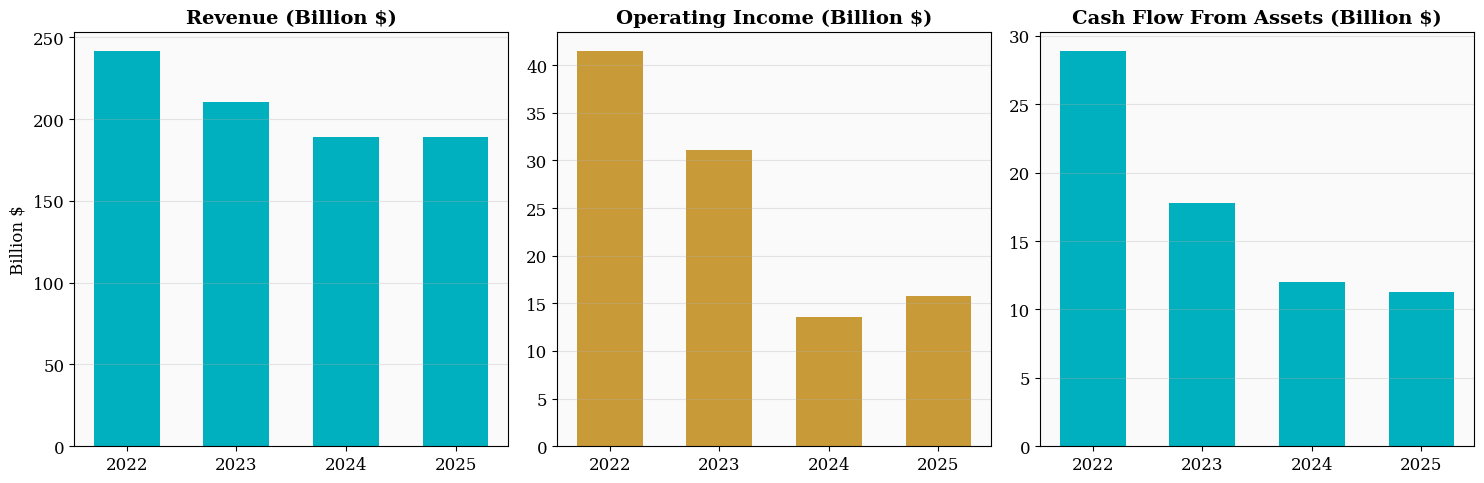

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Revenue
axes[0].bar(years_fs, income_stmt['Revenue'] / 1000, color=C_MEDTEAL, width=0.6)
axes[0].set_title('Revenue (Billion $)', fontweight='bold')
axes[0].set_ylabel('Billion $')
axes[0].grid(axis='y', alpha=0.3)

# Operating Income
axes[1].bar(years_fs, income_stmt['Operating_Income'] / 1000, color=C_MEDBROWN, width=0.6)
axes[1].set_title('Operating Income (Billion $)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Cash Flow From Assets
axes[2].bar(years_fs, cash_flow['CFFA'] / 1000, color=C_MEDTEAL, width=0.6)
axes[2].set_title('Cash Flow From Assets (Billion $)', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.set_xticks(years_fs)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('./report/Figures/Financial-Economics/bp_financial_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Financial Ratio Analysis

=== KEY FINANCIAL RATIOS ===

      Operating_Margin  Net_Margin
Year                              
2022             17.17       -1.03
2023             14.78        7.25
2024              7.20        0.20
2025              8.35        0.03

--- Leverage (2025 Balance Sheet) ---
Debt/Equity:          1.09
Net Debt/EBITDA:      0.85
Interest Coverage:    2.51x


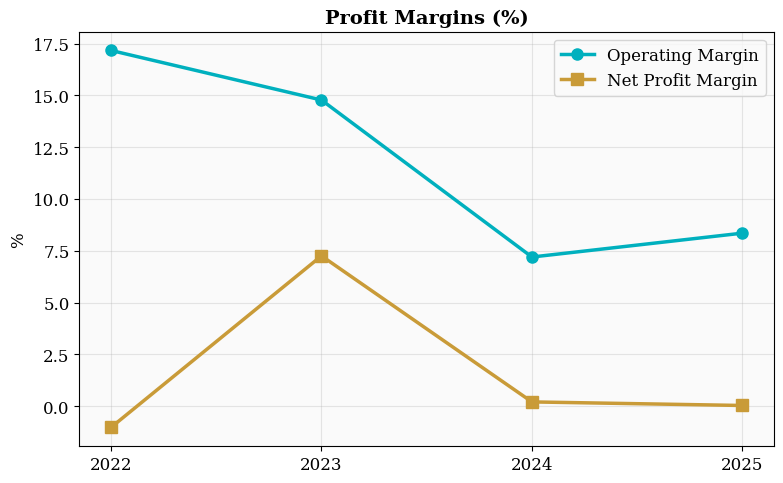

In [ ]:
ratios = pd.DataFrame({
    'Year': years_fs,
    'Operating_Margin': (income_stmt['Operating_Income'] / income_stmt['Revenue'] * 100).values,
    'Net_Margin': (income_stmt['Net_Income'] / income_stmt['Revenue'] * 100).values,
}).set_index('Year')

# Leverage ratios (using latest year balance sheet)
print("=== KEY FINANCIAL RATIOS ===\n")
print(ratios.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(years_fs, ratios['Operating_Margin'], 'o-', color=C_MEDTEAL, linewidth=2.5, markersize=8, label='Operating Margin')
ax.plot(years_fs, ratios['Net_Margin'], 's-', color=C_MEDBROWN, linewidth=2.5, markersize=8, label='Net Profit Margin')
ax.set_title('Profit Margins (%)', fontweight='bold')
ax.set_ylabel('%')
ax.legend()
ax.grid(alpha=0.3)

for a in [ax]:
    a.set_xticks(years_fs)
    a.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('./report/Figures/Financial-Economics/bp_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

## Revenue vs Brent Price Sensitivity

=== BRENT vs BP REVENUE ===
  2022: Brent $99.00/bbl -> Revenue $241,392M
  2023: Brent $82.32/bbl -> Revenue $210,130M
  2024: Brent $79.91/bbl -> Revenue $189,185M
  2025: Brent $68.32/bbl -> Revenue $189,335M

Revenue = 1800.0 × Brent + 59214
R² = 0.854
Interpretation: Each $1 change in Brent -> $1800M change in BP revenue


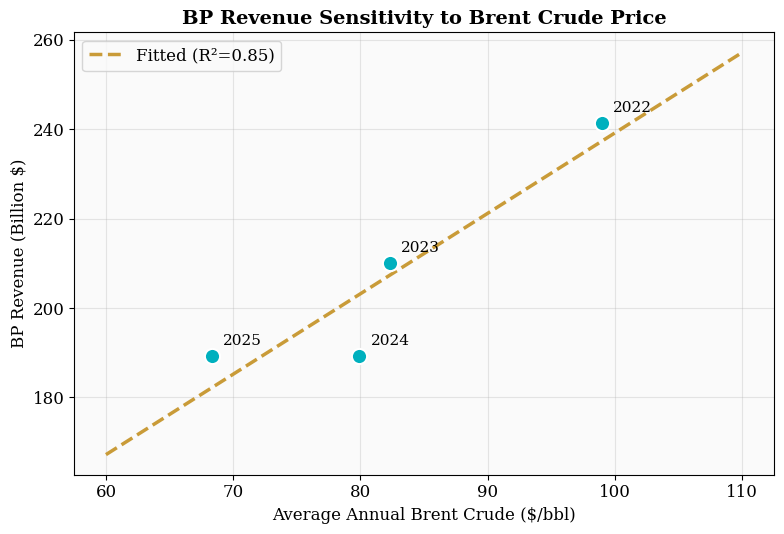

In [ ]:
# Load Brent data
brent = pd.read_csv('./data/POILBREUSDM.csv', parse_dates=['observation_date'])
brent['Year'] = brent['observation_date'].dt.year
brent_annual = brent.groupby('Year')['POILBREUSDM'].mean()

# Get annual averages for BP's fiscal years
brent_for_bp = brent_annual.loc[years_fs].values
revenue_for_bp = income_stmt['Revenue'].values

print("=== BRENT vs BP REVENUE ===")
for y, b, r in zip(years_fs, brent_for_bp, revenue_for_bp):
    print(f"  {y}: Brent ${b:.2f}/bbl -> Revenue ${r:,.0f}M")

# Fit linear regression
X = brent_for_bp.reshape(-1, 1)
y = revenue_for_bp
model = LinearRegression().fit(X, y)
r2 = model.score(X, y)
print(f"\nRevenue = {model.coef_[0]:.1f} × Brent + {model.intercept_:.0f}")
print(f"R² = {r2:.3f}")
print(f"Interpretation: Each $1 change in Brent -> ${model.coef_[0]:.0f}M change in BP revenue")

# plot
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(brent_for_bp, revenue_for_bp / 1000, s=120, color=C_MEDTEAL, zorder=5, edgecolors='white', linewidth=1.5)
x_line = np.linspace(60, 110, 100)
y_line = model.predict(x_line.reshape(-1, 1)) / 1000
ax.plot(x_line, y_line, color=C_MEDBROWN, linewidth=2.5, linestyle='--', label=f'Fitted (R²={r2:.2f})')

for y_val, b, r in zip(years_fs, brent_for_bp, revenue_for_bp):
    ax.annotate(str(y_val), (b, r / 1000), textcoords="offset points", xytext=(8, 8), fontsize=11)

ax.set_xlabel('Average Annual Brent Crude ($/bbl)')
ax.set_ylabel('BP Revenue (Billion $)')
ax.set_title('BP Revenue Sensitivity to Brent Crude Price', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./report/Figures/Financial-Economics/bp_revenue_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## Oil Price Scenarios (5-Year DCF Horizon)

=== OIL PRICE SCENARIOS ($/bbl) ===

  Year    Base Case   Arctic Decline    % Decline
--------------------------------------------------
  2026        68.32            68.12        0.29%
  2027        68.32            68.03        0.43%
  2028        68.32            67.93        0.57%
  2029        68.32            67.84        0.70%
  2030        68.32            67.75        0.84%

Note: Current Brent is ~$105 due to geopolitical events.
I use the 2025 pre-conflict average ($68.32) as the baseline,
acknowledging that prices are volatile and the spike may be temporary.


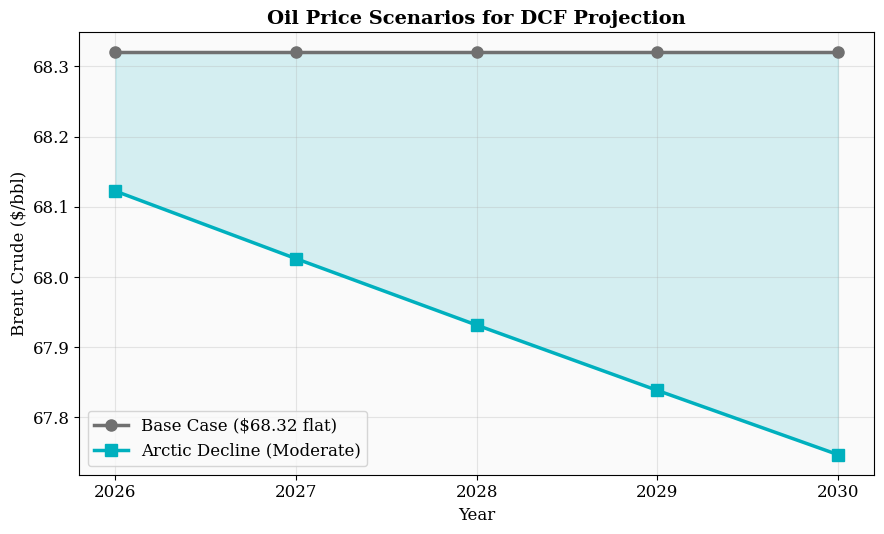

In [14]:
# From thesis: moderate Arctic scenario (10% extraction) produces these % declines
# Using thesis ramp-up logic: norm_ramp over 27 years, first 5 years are small
# I recalculate the year-by-year % decline from the thesis model

arctic_oil = 90_000  # MMBO total
rate = 0.10  # moderate scenario
n_years = 27
ramp = np.linspace(0, 1, n_years)
norm_ramp = ramp / ramp.sum()

# Thesis baseline global oil production (from fitted equation)
beta1_prod = 304.72
beta0_prod = -581891
proj_years = np.arange(2024, 2024 + n_years)
baseline_prod = beta1_prod * proj_years + beta0_prod

# Arctic addition and % supply increase for first 5 years (2025-2030)
oil_add = arctic_oil * rate * norm_ramp
pct_supply_increase = oil_add / baseline_prod
elasticity = 0.50  # Es - Ed = 0.20 - (-0.30)
pct_price_decline = pct_supply_increase / elasticity

# DCF projection years
dcf_years = [2026, 2027, 2028, 2029, 2030]
# Map to thesis ramp indices (year 2 through 6)
dcf_indices = [2, 3, 4, 5, 6]

baseline_price = 68.32  # 2025 annual average from thesis

# Base Case: flat at $68.32
base_prices = [baseline_price] * 5

# Arctic Decline: apply thesis % decline
arctic_prices = [baseline_price * (1 - pct_price_decline[i]) for i in dcf_indices]

print("=== OIL PRICE SCENARIOS ($/bbl) ===\n")
print(f"{'Year':>6s} {'Base Case':>12s} {'Arctic Decline':>16s} {'% Decline':>12s}")
print("-" * 50)
for i, yr in enumerate(dcf_years):
    pct = pct_price_decline[dcf_indices[i]] * 100
    print(f"{yr:>6d} {base_prices[i]:>12.2f} {arctic_prices[i]:>16.2f} {pct:>11.2f}%")

print(f"\nNote: Current Brent is ~$105 due to geopolitical events.")
print(f"I use the 2025 pre-conflict average (${baseline_price}) as the baseline,")
print(f"acknowledging that prices are volatile and the spike may be temporary.")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(dcf_years, base_prices, 'o-', color=C_BASELINE, linewidth=2.5, markersize=8, label='Base Case ($68.32 flat)')
ax.plot(dcf_years, arctic_prices, 's-', color=C_MEDTEAL, linewidth=2.5, markersize=8, label='Arctic Decline (Moderate)')
ax.fill_between(dcf_years, arctic_prices, base_prices, alpha=0.15, color=C_MEDTEAL)
ax.set_xlabel('Year')
ax.set_ylabel('Brent Crude ($/bbl)')
ax.set_title('Oil Price Scenarios for DCF Projection', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(dcf_years)
plt.tight_layout()
plt.savefig('./report/Figures/Financial-Economics/bp_price_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

## Revenue and CFFA Projections

=== PROJECTION ASSUMPTIONS ===
  COGS/Revenue:     83.2%
  OpEx/Revenue:     9.1%
  D&A (flat):       $17,222M
  NCS (flat):       $14,259M
  Delta NWC:        $0M (assumed zero)
  Tax Rate:         35%

=== BASE CASE CFFA PROJECTIONS (Millions $) ===
       Revenue     EBIT     CFFA
Year                            
2026  182188.0  14161.0  12168.0
2027  182188.0  14161.0  12168.0
2028  182188.0  14161.0  12168.0
2029  182188.0  14161.0  12168.0
2030  182188.0  14161.0  12168.0

=== ARCTIC DECLINE CFFA PROJECTIONS (Millions $) ===
       Revenue     EBIT     CFFA
Year                            
2026  181832.0  14134.0  12150.0
2027  181659.0  14120.0  12141.0
2028  181488.0  14107.0  12133.0
2029  181321.0  14094.0  12124.0
2030  181156.0  14081.0  12116.0


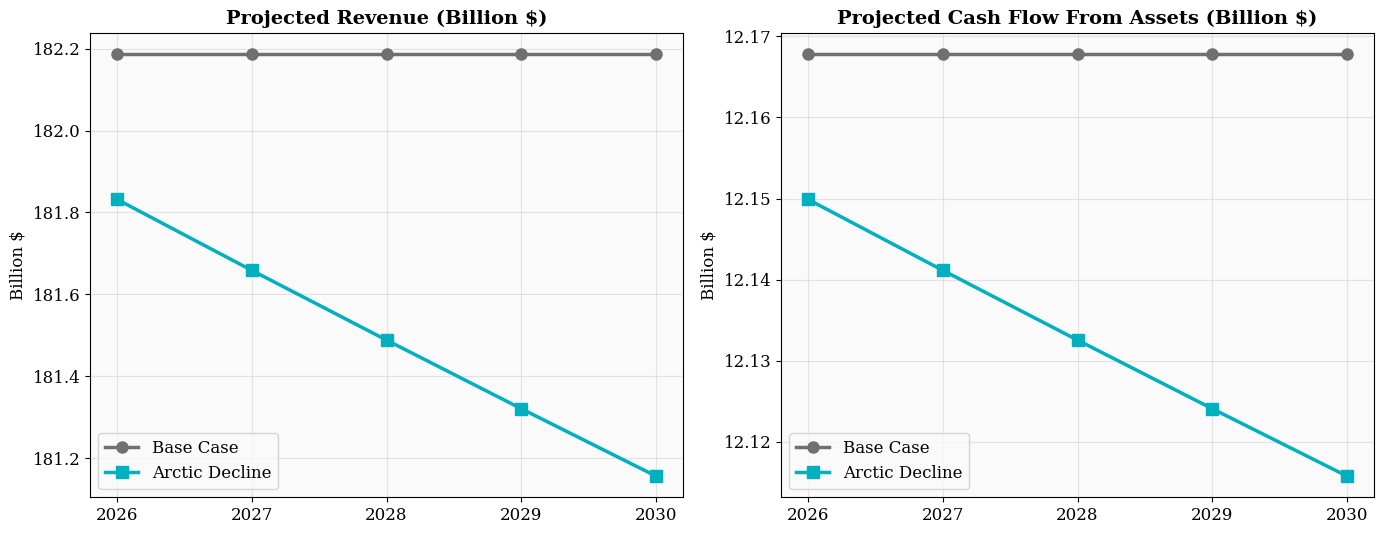

In [15]:
# Revenue projection using sensitivity coefficient
rev_sensitivity = model.coef_[0]  # $ revenue per $1 Brent change
rev_intercept = model.intercept_

base_revenue = [rev_sensitivity * p + rev_intercept for p in base_prices]
arctic_revenue = [rev_sensitivity * p + rev_intercept for p in arctic_prices]

# Operating cost structure (use 2024-2025 average ratios for stability)
avg_cogs_pct = np.mean([
    income_stmt.loc[2024, 'Cost_of_Revenue'] / income_stmt.loc[2024, 'Revenue'],
    income_stmt.loc[2025, 'Cost_of_Revenue'] / income_stmt.loc[2025, 'Revenue'],
])
avg_opex_pct = np.mean([
    income_stmt.loc[2024, 'Operating_Expense'] / income_stmt.loc[2024, 'Revenue'],
    income_stmt.loc[2025, 'Operating_Expense'] / income_stmt.loc[2025, 'Revenue'],
])
avg_da = np.mean([income_stmt.loc[2024, 'DA'], income_stmt.loc[2025, 'DA']])
avg_ncs = np.mean([cash_flow.loc[2024, 'NCS'], cash_flow.loc[2025, 'NCS']])

# Tax rate: use normalized (exclude unusual items)
# Pretax before unusual: EBIT - Interest
# Use average effective on normalized basis
avg_tax_rate = 0.35  # reasonable estimate given BP's global operations
delta_nwc = 0  # Change in Net Working Capital assumed zero (long-term stabilization)

print(f"=== PROJECTION ASSUMPTIONS ===")
print(f"  COGS/Revenue:     {avg_cogs_pct:.1%}")
print(f"  OpEx/Revenue:     {avg_opex_pct:.1%}")
print(f"  D&A (flat):       ${avg_da:,.0f}M")
print(f"  NCS (flat):       ${avg_ncs:,.0f}M")
print(f"  Delta NWC:        ${delta_nwc:,.0f}M (assumed zero)")
print(f"  Tax Rate:         {avg_tax_rate:.0%}")

def project_cffa(revenues, label):
    rows = []
    for i, yr in enumerate(dcf_years):
        rev = revenues[i]
        cogs = rev * avg_cogs_pct
        gross = rev - cogs
        opex = rev * avg_opex_pct
        ebit = gross - opex
        nopat = ebit * (1 - avg_tax_rate)
        # CFFA = OCF - NCS - delta_NWC (textbook Ch.2)
        # OCF = EBIT + DA - Taxes = NOPAT + DA
        cffa = nopat + avg_da - avg_ncs - delta_nwc
        rows.append({
            'Year': yr, 'Revenue': rev, 'EBIT': ebit,
            'NOPAT': nopat, 'CFFA': cffa
        })
    return pd.DataFrame(rows).set_index('Year')

proj_base = project_cffa(base_revenue, 'Base Case')
proj_arctic = project_cffa(arctic_revenue, 'Arctic Decline')

print("\n=== BASE CASE CFFA PROJECTIONS (Millions $) ===")
print(proj_base[['Revenue', 'EBIT', 'CFFA']].round(0).to_string())
print("\n=== ARCTIC DECLINE CFFA PROJECTIONS (Millions $) ===")
print(proj_arctic[['Revenue', 'EBIT', 'CFFA']].round(0).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

ax1.plot(dcf_years, proj_base['Revenue'] / 1000, 'o-', color=C_BASELINE, linewidth=2.5, markersize=8, label='Base Case')
ax1.plot(dcf_years, proj_arctic['Revenue'] / 1000, 's-', color=C_MEDTEAL, linewidth=2.5, markersize=8, label='Arctic Decline')
ax1.set_title('Projected Revenue (Billion $)', fontweight='bold')
ax1.set_ylabel('Billion $')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xticks(dcf_years)

ax2.plot(dcf_years, proj_base['CFFA'] / 1000, 'o-', color=C_BASELINE, linewidth=2.5, markersize=8, label='Base Case')
ax2.plot(dcf_years, proj_arctic['CFFA'] / 1000, 's-', color=C_MEDTEAL, linewidth=2.5, markersize=8, label='Arctic Decline')
ax2.set_title('Projected Cash Flow From Assets (Billion $)', fontweight='bold')
ax2.set_ylabel('Billion $')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xticks(dcf_years)

plt.tight_layout()
plt.savefig('./report/Figures/Financial-Economics/bp_projections.png', dpi=150, bbox_inches='tight')
plt.show()

## WACC Calculation

In [16]:
risk_free = 0.045       # ~4.5% US 10-year Treasury
beta = 0.80             # adjusted historical beta (not the reported -0.22)
market_risk_premium = 0.055  # standard equity risk premium

cost_of_equity = risk_free + beta * market_risk_premium
cost_of_debt = income_stmt.loc[2025, 'Interest_Expense'] / bs['Total_Debt']
tax_rate_wacc = avg_tax_rate

# Weights
equity_weight = market['Market_Cap'] / (market['Market_Cap'] + bs['Total_Debt'])
debt_weight = bs['Total_Debt'] / (market['Market_Cap'] + bs['Total_Debt'])

wacc = equity_weight * cost_of_equity + debt_weight * cost_of_debt * (1 - tax_rate_wacc)

print("=== WACC CALCULATION ===\n")
print(f"  Risk-Free Rate:          {risk_free:.1%}")
print(f"  Beta (adjusted):         {beta:.2f}")
print(f"  Market Risk Premium:     {market_risk_premium:.1%}")
print(f"  Cost of Equity (CAPM):   {cost_of_equity:.2%}")
print(f"  Cost of Debt (pre-tax):  {cost_of_debt:.2%}")
print(f"  Tax Rate:                {tax_rate_wacc:.0%}")
print(f"  Equity Weight:           {equity_weight:.1%}")
print(f"  Debt Weight:             {debt_weight:.1%}")
print(f"\n  ➤ WACC = {wacc:.2%}")
print(f"\n  Note: The reported beta of {market['Beta_Reported']} is distorted by the")
print(f"  recent Iran-US conflict (oil up, equities down). I use {beta:.2f},")
print(f"  consistent with BP's longer-term historical sensitivity to the market.")

=== WACC CALCULATION ===

  Risk-Free Rate:          4.5%
  Beta (adjusted):         0.80
  Market Risk Premium:     5.5%
  Cost of Equity (CAPM):   8.90%
  Cost of Debt (pre-tax):  8.85%
  Tax Rate:                35%
  Equity Weight:           65.9%
  Debt Weight:             34.1%

  ➤ WACC = 7.83%

  Note: The reported beta of -0.22 is distorted by the
  recent Iran-US conflict (oil up, equities down). I use 0.80,
  consistent with BP's longer-term historical sensitivity to the market.


## DCF Valuation

=== DCF VALUATION ===
WACC: 7.83%, Terminal Growth: 2.0%

--- Base Case ---
  PV of CFFAs (5yr):     $      48,805M
  Terminal Value:       $     212,986M
  PV of Terminal:       $     146,120M
  Enterprise Value:     $     194,925M
  - Net Debt:           $      26,127M
  Equity Value:         $     168,798M
  Shares Outstanding:          2,575M
  Intrinsic Value/Share: $      65.55
  Market Price:          $      44.33
  Upside/Downside:            +47.9%

--- Arctic Decline ---
  PV of CFFAs (5yr):     $      48,669M
  Terminal Value:       $     212,074M
  PV of Terminal:       $     145,494M
  Enterprise Value:     $     194,163M
  - Net Debt:           $      26,127M
  Equity Value:         $     168,036M
  Shares Outstanding:          2,575M
  Intrinsic Value/Share: $      65.26
  Market Price:          $      44.33
  Upside/Downside:            +47.2%


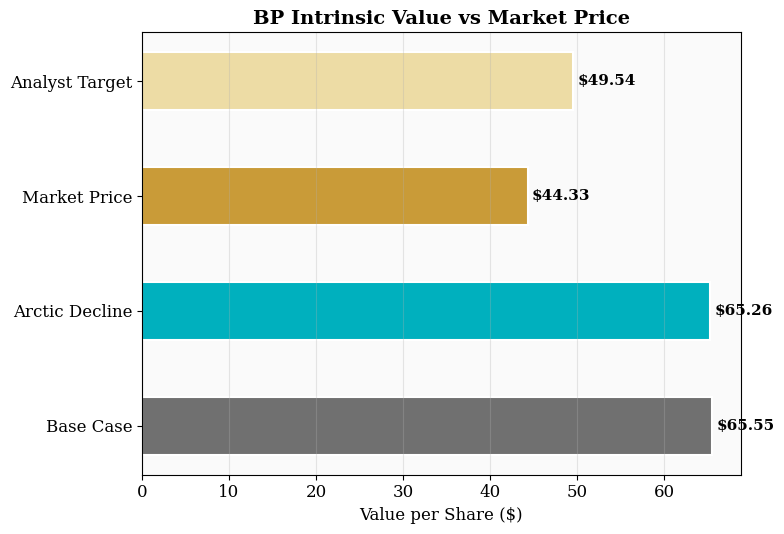

In [17]:
terminal_growth = 0.02  # 2% long-term growth

def dcf_valuation(projected_cffa, wacc_rate, g, label):
    cffas = projected_cffa['CFFA'].values
    n = len(cffas)

    # PV of projected CFFAs
    pv_cffas = sum(cffa / (1 + wacc_rate)**t for t, cffa in enumerate(cffas, 1))

    # Terminal value (Gordon Growth)
    terminal_value = cffas[-1] * (1 + g) / (wacc_rate - g)
    pv_terminal = terminal_value / (1 + wacc_rate)**n

    # Enterprise Value
    ev = pv_cffas + pv_terminal

    # Equity Value
    equity_value = ev - bs['Net_Debt']
    per_share = equity_value / bs['Shares_Outstanding_M']

    print(f"\n--- {label} ---")
    print(f"  PV of CFFAs (5yr):     ${pv_cffas:>12,.0f}M")
    print(f"  Terminal Value:       ${terminal_value:>12,.0f}M")
    print(f"  PV of Terminal:       ${pv_terminal:>12,.0f}M")
    print(f"  Enterprise Value:     ${ev:>12,.0f}M")
    print(f"  - Net Debt:           ${bs['Net_Debt']:>12,.0f}M")
    print(f"  Equity Value:         ${equity_value:>12,.0f}M")
    print(f"  Shares Outstanding:   {bs['Shares_Outstanding_M']:>12,.0f}M")
    print(f"  Intrinsic Value/Share: ${per_share:>11.2f}")
    print(f"  Market Price:          ${market['Price']:>11.2f}")
    upside = (per_share / market['Price'] - 1) * 100
    print(f"  Upside/Downside:       {upside:>+10.1f}%")

    return per_share, ev, equity_value

print("=== DCF VALUATION ===")
print(f"WACC: {wacc:.2%}, Terminal Growth: {terminal_growth:.1%}")

iv_base, ev_base, eq_base = dcf_valuation(proj_base, wacc, terminal_growth, 'Base Case')
iv_arctic, ev_arctic, eq_arctic = dcf_valuation(proj_arctic, wacc, terminal_growth, 'Arctic Decline')

# Comparison chart
fig, ax = plt.subplots(figsize=(8, 5.5))
labels = ['Base Case', 'Arctic Decline', 'Market Price', 'Analyst Target']
values = [iv_base, iv_arctic, market['Price'], market['Analyst_Target']]
colors = [C_BASELINE, C_MEDTEAL, C_MEDBROWN, C_LIGHTBROWN]

bars = ax.barh(labels, values, color=colors, height=0.5, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Value per Share ($)')
ax.set_title('BP Intrinsic Value vs Market Price', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('./report/Figures/Financial-Economics/bp_valuation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()